<a href="https://colab.research.google.com/github/LopintiHari/Git_Projects/blob/master/SED_CNN%26RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Object Detection from an image and Detecting faces from the detected objects

In [ ]:
pip install ultralytics opencv-python

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np

# ---------------- STEP 1: Load YOLOv8n Model ----------------
model = YOLO("yolov8n.pt")  # Automatically downloads if not present

# ---------------- STEP 2: Load Haar Cascade for Face Detection ----------------
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# ---------------- STEP 3: Load Input Image ----------------
image_path = "/content/ManOnBike.webp"
gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if gray is None:
    print("Could not read image.")
    exit()

# ---------------- STEP 4: Preprocess Image ----------------
# Convert grayscale -> RGB for YOLO
image = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
# Enhance contrast (optional)
image[:, :, 0] = cv2.equalizeHist(image[:, :, 0])
image[:, :, 1] = cv2.equalizeHist(image[:, :, 1])
image[:, :, 2] = cv2.equalizeHist(image[:, :, 2])

# ---------------- STEP 5: YOLO Object Detection ----------------
results = model.predict(source=image, conf=0.1)  # Low confidence for grayscale
detections = results[0].boxes.data

# Flag to track if face exists
face_found = False

# ---------------- STEP 6: Loop Through Detected Objects ----------------
for box in detections:
    x1, y1, x2, y2, conf, cls = box.cpu().numpy()
    class_id = int(cls)
    label = model.names[class_id]

    # Draw YOLO object box
    cv2.rectangle(image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    cv2.putText(image, f"{label} ({conf:.2f})", (int(x1), int(y1) - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # ---------------- STEP 7: Check for Face in "person" object ----------------
    if label.lower() == "person":
        person_crop = image[int(y1):int(y2), int(x1):int(x2)]
        gray_crop = cv2.cvtColor(person_crop, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray_crop, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
        if len(faces) > 0:
            face_found = True
            for (fx, fy, fw, fh) in faces:
                cv2.rectangle(person_crop, (fx, fy), (fx + fw, fy + fh), (0, 0, 255), 2)
                cv2.putText(person_crop, "Face", (fx, fy - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

# ---------------- STEP 8: Save and Display Output ----------------
output_path = "output_ManOnBike.jpg"
cv2.imwrite(output_path, image)
print(f"Output saved: {output_path}")

if face_found:
    print("Face detected in the image — keep for training.")
else:
    print("No face detected — discard this image for training.")

cv2.waitKey(0)
cv2.destroyAllWindows()


0: 448x640 1 person, 1 motorcycle, 1 teddy bear, 811.1ms
Speed: 5.4ms preprocess, 811.1ms inference, 6.2ms postprocess per image at shape (1, 3, 448, 640)
✅ Output saved: output_ManOnBike.jpg
✅ Face detected in the image — keep for training.


# Detecting faces in a classroom image and save them for further classification

In [ ]:
!pip install mtcnn
from mtcnn import MTCNN
from google.colab.patches import cv2_imshow # Import cv2_imshow
import cv2
import os

# Load image
image_path = "/content/Classroom_image.jpeg"  # Make sure the image is in your working directory
image = cv2.imread(image_path)

# Initialize MTCNN face detector
detector = MTCNN()

# Detect faces
faces = detector.detect_faces(image)

# Create output directory
output_dir = "extracted_faces"
os.makedirs(output_dir, exist_ok=True)

# Loop through detected faces and save them
for i, face in enumerate(faces):
    x, y, width, height = face['box']
    x, y = max(0, x), max(0, y)
    cropped_face = image[y:y+height, x:x+width]
    cv2_imshow(cropped_face) # Use cv2_imshow for display

    face_filename = os.path.join(output_dir, f"face_{i+1}.jpg")
    cv2.imwrite(face_filename, cropped_face)
    print(f"Saved: {face_filename}")

print(f"\nTotal faces extracted: {len(faces)}")

# Extracting the features from the dataset and map the features with corresponding label and store it in a CSV file for Model training

In [ ]:
from mtcnn import MTCNN
import cv2
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.applications.densenet import preprocess_input

# -------------------------------
# Load Models
# -------------------------------
detector = MTCNN()

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base_model.output)
output = Dense(128)(x)
feature_model = Model(inputs=base_model.input, outputs=output)

# -------------------------------
# Dataset Path
# -------------------------------
dataset_path = "/content/DATASET__128Features_MultiLabels.csv"

emotion_map = {
    "angry":0, "disgust":1, "fear":2,
    "happy":3, "sad":4, "surprise":5, "neutral":6
}

features_list = []
labels = []

# -------------------------------
# LOOP THROUGH DATASET
# -------------------------------
for emotion in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, emotion)

    if not os.path.isdir(folder):
        continue

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        # -------------------------------
        # STEP 1: FACE DETECTION (FILTER)
        # -------------------------------
        faces = detector.detect_faces(img)

        if len(faces) == 0:
            continue   # SKIP image without face

        # -------------------------------
        # STEP 2: PROCESS EACH FACE
        # -------------------------------
        for face in faces:
            x, y, w, h = face['box']
            x, y = max(0, x), max(0, y)

            cropped = img[y:y+h, x:x+w]

            try:
                # -------------------------------
                # STEP 3: PREPROCESS
                # -------------------------------
                cropped = cv2.resize(cropped, (224,224))
                cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
                cropped = preprocess_input(cropped)
                cropped = np.expand_dims(cropped, axis=0)

                # -------------------------------
                # STEP 4: FEATURE EXTRACTION
                # -------------------------------
                features = feature_model.predict(cropped, verbose=0).flatten()

                features_list.append(features)
                labels.append(emotion_map[emotion])

            except:
                continue

# -------------------------------
# SAVE DATASET
# -------------------------------
df = pd.DataFrame(features_list)
df['label'] = labels
df.to_csv("/content/DATASET__128Features_MultiLabels.csv", index=False)

print("Only face images used for training!")

# Random Forest Implementation for FER - 2013 Dataset

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score as accuracy
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

data=pd.read_csv('/content/DATASET__128Features_MultiLabels.csv')
data = data.sample(frac=1).reset_index(drop=True)
X = data.drop('label', axis=1)
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train a classifier (Random Forest)
clf = RandomForestClassifier(n_estimators=300,random_state=42)
model=clf.fit(X_train, y_train)

y_pred=model.predict(X_test)
print(accuracy_score(y_pred,y_test))
print(classification_report(y_test,y_pred,digits=4))

0.8943926534019758
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       968
           1     1.0000    1.0000    1.0000       112
           2     1.0000    1.0000    1.0000      1038
           3     0.7346    0.9081    0.8122      1807
           4     0.7953    0.5210    0.6296      1238
           5     1.0000    1.0000    1.0000      1230
           6     1.0000    1.0000    1.0000       794

    accuracy                         0.8944      7187
   macro avg     0.9328    0.9184    0.9203      7187
weighted avg     0.8980    0.8944    0.8890      7187



In [ ]:
import joblib
from mtcnn import MTCNN
import cv2
import numpy as np
from tensorflow.keras.applications.densenet import preprocess_input

# Load models
detector = MTCNN()
rf_model = joblib.load("emotion_rf.pkl")

# Load classroom image
image = cv2.imread("classroom.jpg")

faces = detector.detect_faces(image)

predicted_emotions = []

for face in faces:
    x, y, w, h = face['box']
    x, y = max(0, x), max(0, y)

    cropped = image[y:y+h, x:x+w]

    try:
        cropped = cv2.resize(cropped, (224,224))
        cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
        cropped = preprocess_input(cropped)
        cropped = np.expand_dims(cropped, axis=0)

        # Feature extraction
        features = feature_model.predict(cropped, verbose=0).flatten()

        # Emotion prediction
        pred = rf_model.predict([features])[0]

        predicted_emotions.append(pred)

    except:
        continue

# Convert labels to emotion names
label_map = {
    0:"Angry", 1:"Disgust", 2:"Fear",
    3:"Happy", 4:"Sad", 5:"Surprise", 6:"Neutral"
}

predicted_emotions = [label_map[p] for p in predicted_emotions]

print("Detected Emotions:", predicted_emotions)

# Emotion-to-Engagement Mapping and Classroom Engagement Evaluation Module

In [ ]:
from collections import Counter

# ----------------------------
# Emotion → Engagement Mapping
# ----------------------------

engaged_emotions = {"Happy", "Neutral", "Surprise"}
disengaged_emotions = {"Angry", "Disgust", "Fear", "Sad"}

def map_emotion_to_engagement(emotion):
    if emotion in engaged_emotions:
        return "Engaged"
    else:
        return "Disengaged"


# ----------------------------
# Final Engagement Calculation
# ----------------------------

def calculate_class_engagement(predicted_emotions):
    """
    predicted_emotions: list of emotions from your trained model
    Example: ["Happy", "Sad", "Neutral", "Fear", ...]
    """

    # Map each emotion → engagement
    engagement_list = [map_emotion_to_engagement(e) for e in predicted_emotions]

    # Count
    count = Counter(engagement_list)
    engaged_count = count["Engaged"]
    disengaged_count = count["Disengaged"]

    # Final decision (majority)
    if engaged_count > disengaged_count:
        final_status = "Class Engaged"
    else:
        final_status = "Class Disengaged"

    # Optional: ratio-based insight
    total = engaged_count + disengaged_count
    engagement_ratio = engaged_count / total if total > 0 else 0

    return {
        "Engaged": engaged_count,
        "Disengaged": disengaged_count,
        "Engagement Ratio": round(engagement_ratio, 2),
        "Final Status": final_status
    }

In [ ]:
# Example output from your trained model (per face)
predicted_emotions = ["Happy", "Sad", "Neutral", "Fear", "Surprise", "Happy"]

result = calculate_class_engagement(predicted_emotions)

print(result)

{'Engaged': 4, 'Disengaged': 2, 'Engagement Ratio': 0.67, 'Final Status': 'Class Engaged'}


In [ ]:
def get_engagement_level(ratio):
    if ratio > 0.7:
        return "Highly Engaged"
    elif ratio > 0.4:
        return "Moderately Engaged"
    else:
        return "Low Engagement"

# Finding misclassified samples after training the Random Forest Model and using cosine similarity

Test accuracy: 0.9016279393349103


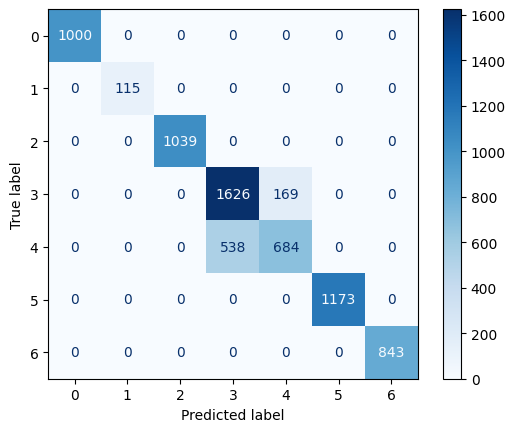


Number of misclassified samples: 707

✅ Process completed successfully.
File saved as: Final_Misclassified_Refined_CosineSimilarity.csv
Columns included:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', 'orig_index', 'true_label', 'pred_label', 'sim_class3', 's

In [ ]:
# ----------------- Import Libraries -----------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# ----------------- Load and Prepare Data -----------------
data = pd.read_csv('/content/DATASET__128Features_MultiLabels.csv')
data = data.sample(frac=1).reset_index(drop=True)   # Shuffle data

X = data.drop('label', axis=1)
y = data['label']

# Store original indices before split (to trace misclassified rows)
X['orig_index'] = X.index

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------- Train Random Forest Classifier -----------------
clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_train.drop('orig_index', axis=1), y_train)

# ----------------- Predictions -----------------
y_predTest = clf.predict(X_test.drop('orig_index', axis=1))
accuracyTest = accuracy_score(y_test, y_predTest)
print("Test accuracy:", accuracyTest)

# ----------------- Confusion Matrix -----------------
cm = confusion_matrix(y_test, y_predTest)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap="Blues", values_format='d')
plt.show()

# ----------------- Identify Misclassified Points -----------------
misclassified_mask = (y_test != y_predTest)
X_mis = X_test[misclassified_mask]
y_true_mis = y_test[misclassified_mask]
y_pred_mis = y_predTest[misclassified_mask]

# Create DataFrame for misclassified samples
mis_df = X_mis.copy()
mis_df['true_label'] = y_true_mis.values
mis_df['pred_label'] = y_pred_mis
print("\nNumber of misclassified samples:", len(mis_df))

# ----------------- Similarity Check (Cosine Similarity) -----------------
# Compute centroids for class 3 and class 4 from training data
centroid_3 = X_train[y_train == 3].drop('orig_index', axis=1).mean(axis=0).values.reshape(1, -1)
centroid_4 = X_train[y_train == 4].drop('orig_index', axis=1).mean(axis=0).values.reshape(1, -1)

# Initialize columns for similarity and refined labels
mis_df['sim_class3'] = np.nan
mis_df['sim_class4'] = np.nan
mis_df['refined_label'] = np.nan

# Compute cosine similarities and refined labels
for i, row in mis_df.iterrows():
    x = row.drop(['orig_index', 'true_label', 'pred_label', 'sim_class3', 'sim_class4', 'refined_label']).values.reshape(1, -1)
    sim_3 = cosine_similarity(x, centroid_3)[0][0]
    sim_4 = cosine_similarity(x, centroid_4)[0][0]

    mis_df.at[i, 'sim_class3'] = sim_3
    mis_df.at[i, 'sim_class4'] = sim_4

    # Assign refined label
    if sim_3 > sim_4:
        mis_df.at[i, 'refined_label'] = 3
    elif sim_4 > sim_3:
        mis_df.at[i, 'refined_label'] = 4
    else:
        mis_df.at[i, 'refined_label'] = np.nan  # ambiguous

# ----------------- Save Final CSV -----------------
output_file = "Final_Misclassified_Refined_CosineSimilarity.csv"
mis_df.to_csv(output_file, index=False)

print("\n✅ Process completed successfully.")
print(f"File saved as: {output_file}")
print("Columns included:")
print(list(mis_df.columns))


## After Finding misclassified samples betweeen classes 3 and 4 and then applying cosine similarity to the classes and then finding the accuracy overall

Initial Test Accuracy:  0.8982885765966329


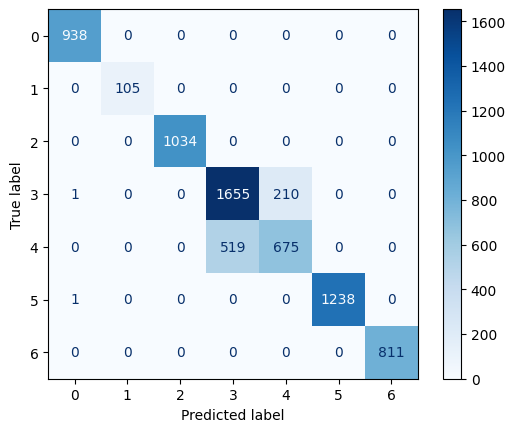


Misclassified Samples:
         0         1         2    3         4    5         6         7  \
34957  0.0  0.000000  0.006309  0.0  0.006410  0.0  0.087385  0.045406   
3386   0.0  0.001283  0.002619  0.0  0.006745  0.0  0.054313  0.034447   
25839  0.0  0.007662  0.001520  0.0  0.000000  0.0  0.045259  0.039845   
21801  0.0  0.009862  0.004842  0.0  0.014081  0.0  0.069618  0.031673   
6596   0.0  0.002064  0.000000  0.0  0.004138  0.0  0.047055  0.031044   

              8         9  ...       120       121       122       123  \
34957  0.000000  0.074148  ...  0.014125  0.028626  0.025186  0.000000   
3386   0.000000  0.043310  ...  0.016850  0.015009  0.013513  0.012399   
25839  0.003337  0.053126  ...  0.016189  0.017217  0.000000  0.005965   
21801  0.002906  0.041995  ...  0.006892  0.020091  0.028054  0.017222   
6596   0.000000  0.049512  ...  0.010778  0.011101  0.009285  0.003733   

            124  125  126       127  true_label  pred_label  
34957  0.007769  0.0  0.

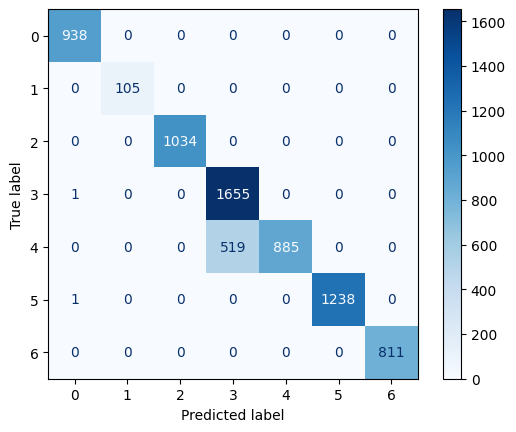

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# ----------------- Step 0: Load and Prepare Data -----------------
data = pd.read_csv('/content/DATASET__128Features_MultiLabels.csv')
data = data.sample(frac=1).reset_index(drop=True)   # Shuffle

X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------- Step 1: Train initial classifier -----------------
clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_train, y_train)

y_predTest = clf.predict(X_test)
accuracyTest = accuracy_score(y_test, y_predTest)
print("Initial Test Accuracy: ", accuracyTest)

# Confusion Matrix
cm = confusion_matrix(y_test, y_predTest)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4,5,6])
disp.plot(cmap="Blues", values_format='d')
plt.show()

# ----------------- Step 2: Identify Misclassified Points (3<->4) -----------------
mis_3_as_4 = np.where((y_test.values == 3) & (y_predTest == 4))[0]
mis_4_as_3 = np.where((y_test.values == 4) & (y_predTest == 3))[0]

misclassified_indices = np.concatenate([mis_3_as_4, mis_4_as_3])        # Gather all misclassified sample positions into one place.
X_mis = X_test.iloc[misclassified_indices]                              # Extract the features (inputs) of misclassified samples.
y_true_mis = y_test.iloc[misclassified_indices]                         # Collect the truth labels of the misclassified samples
y_pred_mis = y_predTest[misclassified_indices]                          # Collect the wrong predictions.

mis_df = X_mis.copy()
mis_df['true_label'] = y_true_mis.values
mis_df['pred_label'] = y_pred_mis

print("\nMisclassified Samples:")
print(mis_df.head())

mis_df.to_csv("misclassified_samples.csv", index=False)

# ----------------- Step 3: Refine Labels using Cosine Similarity -----------------
centroid_3 = X_train[y_train == 3].mean(axis=0).values.reshape(1, -1)
centroid_4 = X_train[y_train == 4].mean(axis=0).values.reshape(1, -1)

# print("Centroid values of class 3 and 4: ")
# print(centroid_3)
# print(centroid_4)

refined_labels = {}
for i, row in X_mis.iterrows():
    x = row.values.reshape(1, -1)
    sim_3 = cosine_similarity(x, centroid_3)[0][0]
    sim_4 = cosine_similarity(x, centroid_4)[0][0]

    if sim_3 > sim_4:
        refined_labels[i] = 3
    elif sim_4 > sim_3:
        refined_labels[i] = 4
    else:
        refined_labels[i] = None   # ambiguous

refined_df = mis_df.copy()
refined_df['refined_label'] = refined_df.index.map(refined_labels)
print("\nRefined Misclassified Samples:")
print(refined_df.head())

refined_df.to_csv("refined_misclassified_samples.csv", index=False)

# ----------------- Step 4: Update Test Labels -----------------
y_test_updated = y_test.copy()
for idx, new_label in refined_labels.items():
    if new_label is not None:
        y_test_updated.loc[idx] = new_label

# ----------------- Step 5: Retrain or Refine Predictions -----------------
retrain_model = True   # Set False to just refine predictions without retraining

if retrain_model:
    # Retrain classifier on full training set
    clf.fit(X_train, y_train)
    y_pred_updated = clf.predict(X_test)
else:
    # Just refine existing predictions
    y_pred_updated = y_predTest.copy()
    for idx, new_label in refined_labels.items():
        if new_label is not None:
            y_pred_updated[idx] = new_label

# ----------------- Step 6: Evaluate -----------------
print("\nUpdated Test Accuracy:", accuracy_score(y_test_updated, y_pred_updated))
print("\nClassification Report (Updated Test Set):")
from sklearn.metrics import classification_report
print(classification_report(y_test_updated, y_pred_updated))

cm_updated = confusion_matrix(y_test_updated, y_pred_updated)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_updated, display_labels=[0,1,2,3,4,5,6])
disp.plot(cmap="Blues", values_format='d')
plt.show()

# ----------------- Optional: Save Updated Test Labels -----------------
# updated_test_df = X_test.copy()
# updated_test_df['label'] = y_test_updated
# updated_test_df.to_csv("X_test_updated_labels.csv", index=False)


## TRAIN AND TEST WITH 5 CLASSES BY REMOVING CLASSES 3 & 4,Because major misclassifications lies in 3 & 4 classes

Training Accuracy: 99.98794236450233
Test Accuracy: 100.0


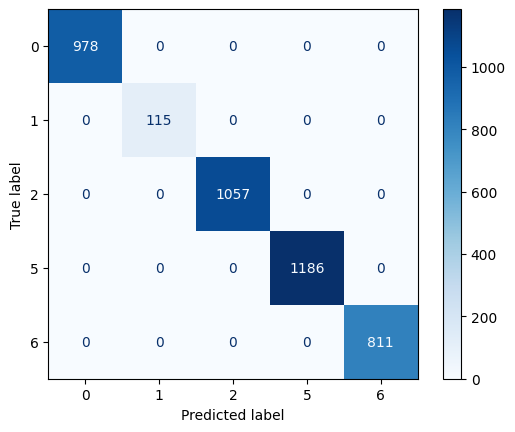

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ----------------- Step 0: Load data -----------------
data = pd.read_csv('/content/DATASET__128Features_MultiLabels.csv')

# ----------------- Step 1: Remove classes 3 and 4 -----------------
data_filtered = data[~data['label'].isin([3, 4])].reset_index(drop=True)

X = data_filtered.drop('label', axis=1)
y = data_filtered['label']

# ----------------- Step 2: Split data -----------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------- Step 3: Train Random Forest -----------------
clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_train, y_train)

# ----------------- Step 4: Make predictions -----------------
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

# ----------------- Step 5: Evaluate -----------------
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Training Accuracy:", train_acc*100)
print("Test Accuracy:", test_acc*100)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(cmap="Blues", values_format='d')
plt.show()


## Hybrid model for finding similarity scores for misclassified samples using COSINE SIMILARITY,EUCLIDEAN AND MAHALANOBIS

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean, mahalanobis
import matplotlib.pyplot as plt

# ----------------- Step 0: Load and Prepare Data -----------------
data = pd.read_csv('/content/DATASET__128Features_MultiLabels.csv')
data = data.sample(frac=1).reset_index(drop=True)

X = data.drop('label', axis=1)
y = data['label']

X['orig_index'] = X.index

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------- Step 1: Train classifier -----------------
clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_train.drop('orig_index', axis=1), y_train)

y_predTest = clf.predict(X_test.drop('orig_index', axis=1))
print("Initial Test Accuracy:", accuracy_score(y_test, y_predTest))

# ----------------- Step 2: Compute Centroids and Covariance -----------------
centroid_3 = X_train[y_train == 3].drop('orig_index', axis=1).mean(axis=0).values
centroid_4 = X_train[y_train == 4].drop('orig_index', axis=1).mean(axis=0).values

train_34 = np.vstack([
    X_train[y_train == 3].drop('orig_index', axis=1).values,
    X_train[y_train == 4].drop('orig_index', axis=1).values
])
cov = np.cov(train_34.T)
inv_cov = np.linalg.pinv(cov)

# ----------------- Step 3: Find Misclassified 3↔4 -----------------
mis_3_as_4 = np.where((y_test.values == 3) & (y_predTest == 4))[0]
mis_4_as_3 = np.where((y_test.values == 4) & (y_predTest == 3))[0]
misclassified_indices = np.concatenate([mis_3_as_4, mis_4_as_3])
print(f"Total misclassified (3↔4): {len(misclassified_indices)}")

results = []

# ----------------- Step 4: Refine Misclassified Samples -----------------
for idx in misclassified_indices:
    row = X_test.iloc[idx]
    x = row.drop('orig_index').values

    # Compute raw similarities/distances
    cos3 = cosine_similarity([x], [centroid_3])[0][0]
    cos4 = cosine_similarity([x], [centroid_4])[0][0]

    eu3 = euclidean(x, centroid_3)
    eu4 = euclidean(x, centroid_4)

    mah3 = mahalanobis(x, centroid_3, inv_cov)
    mah4 = mahalanobis(x, centroid_4, inv_cov)

    # Convert distances → similarities and normalize all to [0, 1]
    eu3_sim = 1 / (1 + eu3)
    eu4_sim = 1 / (1 + eu4)
    mah3_sim = 1 / (1 + mah3)
    mah4_sim = 1 / (1 + mah4)

    # Normalize cosine to [0, 1] explicitly (range can be -1 to 1)
    cos3_norm = (cos3 + 1) / 2
    cos4_norm = (cos4 + 1) / 2

    # Aggregate overall similarity for each class (average of 3 normalized metrics)
    sim3_final = np.mean([cos3_norm, eu3_sim, mah3_sim])
    sim4_final = np.mean([cos4_norm, eu4_sim, mah4_sim])

    # Determine final label based on higher aggregated similarity
    if sim3_final > sim4_final:
        refined_label = 3
        final_similarity_score = sim3_final
    else:
        refined_label = 4
        final_similarity_score = sim4_final

    # Store results
    results.append({
        "orig_index": row["orig_index"],
        **{f: row[f] for f in X_test.columns if f != "orig_index"},
        "true_label": y_test.iloc[idx],
        "pred_label": y_predTest[idx],
        "cosine_3": cos3,
        "cosine_4": cos4,
        "euclidean_3": eu3,
        "euclidean_4": eu4,
        "mahalanobis_3": mah3,
        "mahalanobis_4": mah4,
        "sim3_final": sim3_final,
        "sim4_final": sim4_final,
        "final_similarity_score": final_similarity_score,
        "refined_label": refined_label
    })

# ----------------- Step 5: Save Results -----------------
final_df = pd.DataFrame(results)
final_file = "Misclassified_Samples_With_Normalized_Similarity.csv"
final_df.to_csv(final_file, index=False)

print(f"\nProcess completed successfully. File saved as: {final_file}")
print(list(final_df.columns))

# ----------------- Step 6: Evaluate -----------------
y_pred_refined = y_predTest.copy()
for idx, new_label in zip(misclassified_indices, final_df['refined_label']):
    y_pred_refined[idx] = new_label

print("\nUpdated Test Accuracy:", accuracy_score(y_test, y_pred_refined))
print("\nClassification Report (After Refinement):")
print(classification_report(y_test, y_pred_refined))

cm_updated = confusion_matrix(y_test, y_pred_refined)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_updated, display_labels=sorted(y.unique()))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix After Similarity Correction (3 vs 4)")
plt.show()


# Checking the trained model on new Image with same number of features are extracted and fed into the trained model

In [ ]:
# ----------------------------
# PART 1: Train and Save RF Model
# ----------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import matplotlib.pyplot as plt
import joblib  # to save/load RF model

# Load dataset
data = pd.read_csv('/content/DATASET__128Features_MultiLabels.csv')
data = data.sample(frac=1).reset_index(drop=True)   # Shuffle

X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train RandomForest
clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_predTest = clf.predict(X_test)
print("Initial Test Accuracy:", accuracy_score(y_test, y_predTest))

cm = confusion_matrix(y_test, y_predTest)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(cmap="Blues", values_format='d')
plt.show()

# ----------------------------
# Save RF model using joblib
# ----------------------------
joblib.dump(clf, "trained_rf_model.pkl")
print("RandomForest model saved as trained_rf_model.pkl")

# ----------------------------
# PART 2: Load CNN & Extract Features from New Image
# ----------------------------
import os
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the same CNN used to extract features
def build_base_cnn(feature_dim=128, input_shape=(48, 48, 1)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    features = layers.Dense(feature_dim, activation=None, name="features")(x)
    model = models.Model(inputs=inputs, outputs=features)
    return model

base_cnn = build_base_cnn(feature_dim=128, input_shape=(48,48,1))

# Load CNN weights if you have saved trained weights
# base_cnn.load_weights("cnn_trained_weights.h5")

# ----------------------------
# Load and preprocess new image
# ----------------------------
def preprocess_image(img_path, img_size=(48,48)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image not found: {img_path}")
    img = cv2.resize(img, img_size)
    img = img.astype("float32") / 255.0
    img = img.reshape(1, img_size[0], img_size[1], 1)  # add batch dimension
    return img
# Example: new image path
test_image_path = "/content/Fear_testImage4.jpg"
X_new_img = preprocess_image(test_image_path)

# ----------------------------
# Extract 128 features
# ----------------------------
features_new = base_cnn.predict(X_new_img)
print("Extracted feature vector shape:", features_new.shape)  # (1,128)

# Convert to DataFrame for RF
import pandas as pd
feature_df = pd.DataFrame(features_new, columns=[f"{i}" for i in range(features_new.shape[1])])

# ----------------------------
# PART 3: Load RF model and Predict
# ----------------------------
clf_loaded = joblib.load("trained_rf_model.pkl")
pred_label = clf_loaded.predict(feature_df)
print(f"Predicted class for the new image: {pred_label[0]}")

# For finding the samples having true label as 3 but predicted as 4 even after refinement using Cosine similarity

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import joblib

# --------- 1) Custom serializable layer (replaces Lambda) ----------
@tf.keras.utils.register_keras_serializable(package="preproc")
class RgbToGray(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def call(self, inputs):
        return tf.image.rgb_to_grayscale(inputs)
    def get_config(self):
        return super().get_config()

# --------- 2) Base CNN (same as your training) ----------
def build_base_cnn(feature_dim=128, input_shape=(48, 48, 1)) -> tf.keras.Model:
    inputs = layers.Input(shape=input_shape, name="gray_input")
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same", name="conv1")(inputs)
    x = layers.MaxPooling2D((2,2), name="pool1")(x)
    x = layers.Conv2D(64, (3,3), activation="relu", padding="same", name="conv2")(x)
    x = layers.MaxPooling2D((2,2), name="pool2")(x)
    x = layers.Conv2D(128, (3,3), activation="relu", padding="same", name="conv3")(x)
    x = layers.MaxPooling2D((2,2), name="pool3")(x)
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(256, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    features = layers.Dense(feature_dim, activation=None, name="features")(x)
    return models.Model(inputs=inputs, outputs=features, name="BaseCNN")

# --------- 3) Wrap preprocessing inside the model ----------
def build_rgb_feature_extractor(base_cnn: tf.keras.Model,
                                fixed_input_size: bool = False) -> tf.keras.Model:
    if fixed_input_size:
        rgb_input = layers.Input(shape=(48, 48, 3), name="rgb_input")
        x = rgb_input
    else:
        rgb_input = layers.Input(shape=(None, None, 3), name="rgb_input")
        x = layers.Resizing(48, 48, name="resize_to_48")(rgb_input)

    x = RgbToGray(name="to_gray")(x)             # <- custom layer instead of Lambda
    x = layers.Rescaling(1./255.0, name="rescale_0_1")(x)
    features = base_cnn(x)
    return models.Model(inputs=rgb_input, outputs=features, name="RGBtoFeatures")

# --------- 4) Build, (optionally) load weights, and SAVE ----------
CNN_WEIGHTS_PATH = "/content/base_cnn_weights.h5"                # (optional)
KERAS_PATH       = "/content/face_feature_extractor.keras"       # native Keras format
SAVEDMODEL_DIR   = "/content/face_feature_extractor_savedmodel"  # for TF Serving/TFLite

base_cnn = build_base_cnn(feature_dim=128, input_shape=(48,48,1))
if os.path.exists(CNN_WEIGHTS_PATH):
    base_cnn.load_weights(CNN_WEIGHTS_PATH)
    print("Loaded CNN weights from:", CNN_WEIGHTS_PATH)
else:
    print(f"CNN weights not found at {CNN_WEIGHTS_PATH}. "
          "Saving a randomly-initialized model (not recommended for inference).")

feature_extractor = build_rgb_feature_extractor(base_cnn, fixed_input_size=False)
feature_extractor.trainable = False

# Save (new Keras format) and export SavedModel
feature_extractor.save(KERAS_PATH)
print("Model saved as:", KERAS_PATH)
feature_extractor.export(SAVEDMODEL_DIR)
print("Exported SavedModel to:", SAVEDMODEL_DIR)

# --------- 5) Safe load (now works in safe mode) ----------
loaded = tf.keras.models.load_model(KERAS_PATH)  # no need for safe_mode=False

# --------- 6) Use on an RGB face (NumPy) ----------
def features_from_rgb_array(face_rgb: np.ndarray) -> np.ndarray:
    if face_rgb is None:
        raise ValueError("face_rgb is None.")
    if face_rgb.ndim != 3 or face_rgb.shape[2] != 3:
        raise ValueError(f"Expected RGB shape (H,W,3), got {face_rgb.shape}")
    # Keras signature expects float32; we’ll pass float32 and let Rescaling handle [0,255] -> [0,1]
    x = face_rgb.astype(np.float32)
    x = np.expand_dims(x, 0)  # (1,H,W,3)
    feats = loaded.predict(x, verbose=0)  # (1,128)
    return feats[0].astype(np.float32)

def features_from_path(path: str) -> np.ndarray:
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return features_from_rgb_array(rgb)

# Example
fv = features_from_path("/content/Fear_testImage5.jpg")
print("Feature vector shape:", fv.shape)  # (128,)


# =========================================================
# 5) Connect to your Random Forest for emotion prediction
rf = joblib.load("/content/Random_Forest_Model_Emotion_Classification.pkl")

# If you trained with integer labels 0..6, use this mapping:
emotions_map = {0:"angry", 1:"disgust", 2:"fear",  3:"happy", 4:"neutral", 5:"sad", 6:"surprise"}

# Inspect classes to confirm mapping
print("RF classes_:", rf.classes_)

# Predict
fv_2d = fv.reshape(1, -1)
pred = rf.predict(fv_2d)[0]
probs = rf.predict_proba(fv_2d)[0]

pred_label = emotions_map.get(int(pred), f"unknown({pred})")
print("Predicted emotion:", pred_label)